# XOR Neural Network Experiment

Bu çalışmada XOR problemini çözmek için çok katmanlı yapay sinir ağı kullanılmıştır.

Tek katmanlı perceptronlar XOR problemini çözemediği için gizli katman içeren bir MLP modeli oluşturulmuştur.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# XOR veri seti

X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([
    0,
    1,
    1,
    0
])

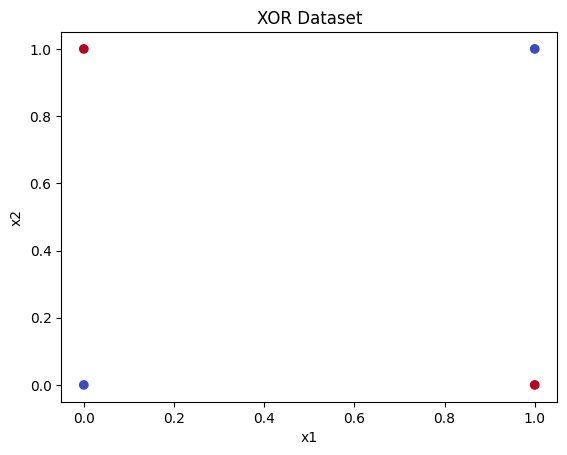

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Dataset")

plt.show()

tek dogru ile ayirmak mumkun degil

In [ ]:
# tek katmanli model
model = Sequential()

model.add(Dense(1, input_dim=2, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model egitimi
history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

In [ ]:
# tahmmin
predictions = model.predict(X)

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[0.51108766]
 [0.49386182]
 [0.5084465 ]
 [0.4912202 ]]


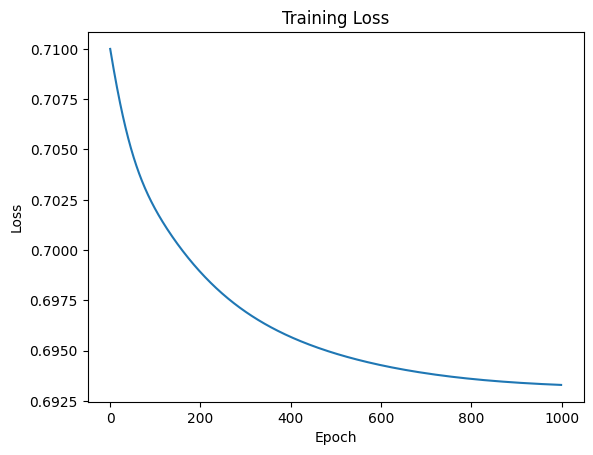

In [ ]:
# loss grafigi
plt.plot(history.history['loss'])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [ ]:
# 2 dense MLP
model = Sequential()

model.add(Dense(2, input_dim=2, activation='tanh'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# MLP egit
history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

In [ ]:
pred = model.predict(X)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
[[0.17727003]
 [0.65831065]
 [0.64952224]
 [0.13940586]]


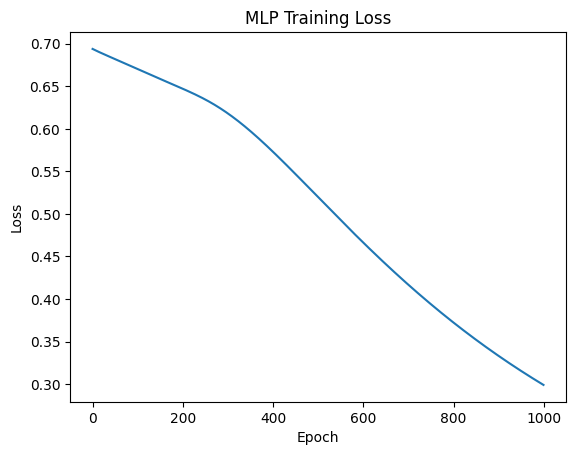

In [ ]:
plt.plot(history.history['loss'])

plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [ ]:
# epoch degis 1000-> 5000, tanh, 2 noron
history = model.fit(
    X,
    y,
    epochs=5000,
    verbose=0
)

In [ ]:
pred = model.predict(X)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[0.00929833]
 [0.4975535 ]
 [0.9907776 ]
 [0.5025966 ]]


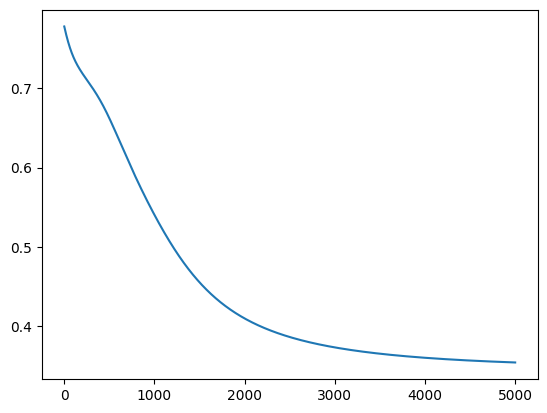

In [ ]:
plt.plot(history.history['loss'])

In [ ]:
hidden_model = Sequential()

hidden_model.add(Dense(2, input_dim=2, activation='tanh'))

hidden_model.set_weights(model.layers[0].get_weights())

hidden_output = hidden_model.predict(X)

print(hidden_output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[-0.9399987  -0.5471411 ]
 [-0.99999547  0.9949376 ]
 [ 0.8378759   0.9289813 ]
 [-0.9982957   0.9999453 ]]


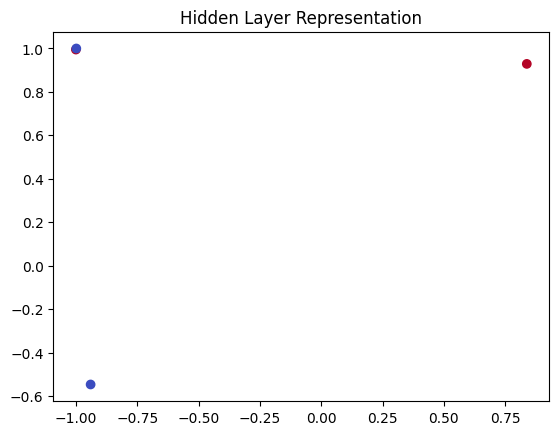

In [ ]:
plt.scatter(
    hidden_output[:,0],
    hidden_output[:,1],
    c=y,
    cmap='coolwarm'
)

plt.title("Hidden Layer Representation")

plt.show()

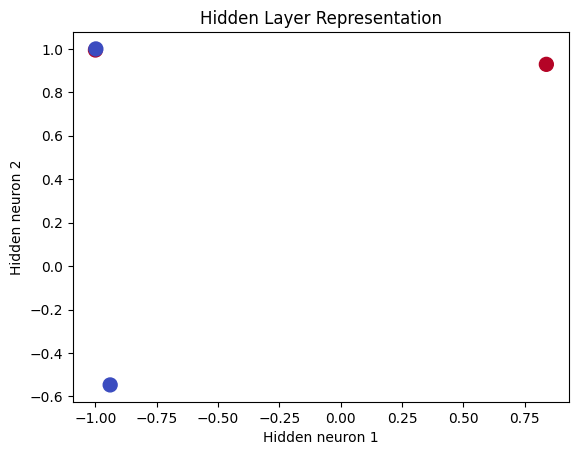

In [ ]:
plt.scatter(
    hidden_output[:,0],
    hidden_output[:,1],
    c=y,
    cmap='coolwarm',
    s=100
)

plt.xlabel("Hidden neuron 1")
plt.ylabel("Hidden neuron 2")

plt.title("Hidden Layer Representation")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


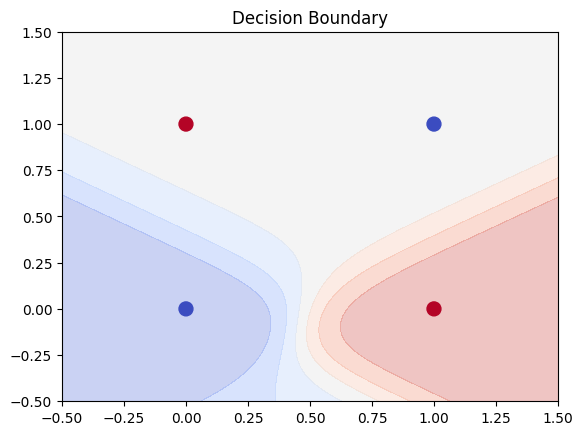

In [ ]:
# model XOR'u nasıl ayırıyor
import numpy as np

xx, yy = np.meshgrid(
    np.linspace(-0.5, 1.5, 100),
    np.linspace(-0.5, 1.5, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred = model.predict(grid)

pred = pred.reshape(xx.shape)

plt.contourf(xx, yy, pred, alpha=0.3, cmap='coolwarm')

plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', s=100)

plt.title("Decision Boundary")

plt.show()

In [ ]:
# hidden neuron sayısı = 1
model = Sequential()

model.add(Dense(1, input_dim=2, activation='tanh'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X,
    y,
    epochs=5000,
    verbose=0
)

In [ ]:
pred = model.predict(X)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[0.33959177]
 [0.33279595]
 [0.987708  ]
 [0.33557007]]


basarisiz

In [ ]:
#4 noron
model = Sequential()

model.add(Dense(4, input_dim=2, activation='tanh'))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X,
    y,
    epochs=5000,
    verbose=0
)

In [ ]:
pred = model.predict(X)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[[0.00128206]
 [0.97922057]
 [0.99748266]
 [0.01969719]]


## Grid Search Experiments
- hidden neuron sayısı
- aktivasyon fonksiyonu
- optimizer
- epoch sayısı


In [ ]:
import numpy as np
import pandas as pd
from tensorflow import keras
from itertools import product

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

neurons = [2,3,4,5,8]
epochs_list = [1000,3000,5000]
activations = ['relu','tanh','sigmoid']
optimizers = ['adam','sgd']

results = []

for n, e, act, opt in product(neurons, epochs_list, activations, optimizers):

    model = keras.Sequential([
        keras.layers.Dense(n, activation=act, input_shape=(2,)),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X, y, epochs=e, verbose=0)

    loss, acc = model.evaluate(X, y, verbose=0)

    results.append({
        "neurons": n,
        "epochs": e,
        "activation": act,
        "optimizer": opt,
        "accuracy": acc
    })

df = pd.DataFrame(results)

df.sort_values(by="accuracy", ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,neurons,epochs,activation,optimizer,accuracy
8,2,3000,tanh,adam,1.0
66,5,5000,relu,adam,1.0
73,8,1000,relu,sgd,1.0
72,8,1000,relu,adam,1.0
85,8,5000,relu,sgd,1.0
81,8,3000,tanh,sgd,1.0
78,8,3000,relu,adam,1.0
50,4,5000,tanh,adam,1.0
55,5,1000,relu,sgd,1.0
56,5,1000,tanh,adam,1.0


Grid search sonuçlarına göre birçok kombinasyon %100 doğruluk elde etmiştir.

En basit başarılı model:

Hidden neurons: 2
Activation: tanh
Optimizer: adam
Epoch: 3000

Bu sonuç XOR probleminin küçük bir MLP ile öğrenilebildiğini göstermektedir.